<a href="https://colab.research.google.com/github/VictorNzai/DataSprint/blob/main/DataSprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import drive #This wouldd help with the short runtime window that we have
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Loading


In [37]:
import pandas as pd #Starter Code from the Brief
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

df = pd.read_excel('/content/finaccess2024_datasprint.xlsx')

print(df.shape) # (20871, 28)
print(df['financial_status'].value_counts())

# Always evaluate with weighted F1 - not accuracy!
# The variables y_test and y_pred are not defined yet, so these lines should remain commented.
# score = f1_score(y_test, y_pred, average='weighted')
# print(f'Weighted F1: {score:.3f}')

(20871, 28)
financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64


# Data Description



In [38]:
# 1. Display basic information about the DataFrame
# This includes the number of entries, number of columns, data types of each column, and non-null values.
print("\n--- DataFrame Information ---")
df.info()


--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   county                 20871 non-null  object
 1   location_type          20871 non-null  object
 2   Sex                    20871 non-null  object
 3   Age                    20871 non-null  object
 4   household_size         20871 non-null  int64 
 5   education_level        20871 non-null  object
 6   marital_status         20871 non-null  object
 7   monthly_income         20871 non-null  int64 
 8   Savings_formal         20871 non-null  object
 9   Savings_informal       20871 non-null  object
 10  Loan_formal            20871 non-null  object
 11  Loan_informal          20871 non-null  object
 12  defaulted              20871 non-null  object
 13  formal_service_use     20871 non-null  object
 14  mobile_money_access    20871 non-null  

In [39]:
# 2. Display descriptive statistics for numerical columns
# This provides insights into the central tendency, dispersion, and shape of the distribution of numerical data.
print("\n--- Descriptive Statistics for Numerical Columns ---")
print(df.describe())


--- Descriptive Statistics for Numerical Columns ---
       household_size  monthly_income      prodsum1
count    20871.000000    20871.000000  20871.000000
mean         4.215946     9702.774280      3.936563
std          2.512658    15423.366592      3.227992
min          1.000000      100.000000      0.000000
25%          2.000000     2500.000000      1.000000
50%          4.000000     5000.000000      3.000000
75%          6.000000    10000.000000      6.000000
max         20.000000   200000.000000     22.000000


In [40]:
# 3. Display descriptive statistics for categorical columns (including object and boolean types)
# This helps understand the distribution of categorical data, showing count, unique values, top value, and its frequency.
print("\n--- Descriptive Statistics for Categorical Columns ---")
print(df.describe(include='object'))


--- Descriptive Statistics for Categorical Columns ---
       county location_type     Sex    Age         education_level  \
count   20871         20871   20871  20871                   20871   
unique     47             2       2      6                      13   
top      Meru         Rural  Female  26-35  "Secondary completed "   
freq      637         13549   12326   5361                    4113   

                     marital_status Savings_formal Savings_informal  \
count                         20871          20871            20871   
unique                            6              2                2   
top     Married/Living with partner      Non-usage        Non-usage   
freq                          11432          11635            16031   

       Loan_formal Loan_informal  ... experienced_shock nfhi_11 nfhi_12  \
count        20871         20871  ...             20871   20871   20871   
unique           2             2  ...                 2       2       2   
top      Non

# Data Cleaning


In [41]:
# 4. Check for missing values in each column
# This identifies columns with missing data, which is crucial for data cleaning and preprocessing.
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64


In [42]:
#To fill missing values
df['barriers_bank'] = df['barriers_bank'].fillna('No barrier')
print(df.isnull().sum())

county                   0
location_type            0
Sex                      0
Age                      0
household_size           0
education_level          0
marital_status           0
monthly_income           0
Savings_formal           0
Savings_informal         0
Loan_formal              0
Loan_informal            0
defaulted                0
formal_service_use       0
mobile_money_access      0
barriers_mobile_money    0
mobile_ownership_1       0
experienced_shock        0
nfhi_11                  0
nfhi_12                  0
nfhi_13                  0
accessto_13k_1month      0
not_difficult            0
financial_status         0
fl_score                 0
prodsum1                 0
barriers_bank            0
has_disability           0
dtype: int64


In [43]:
# Count and drop total duplicates
df.duplicated().sum()
df = df.drop_duplicates()


In [44]:
# 5. Display the number of unique values for each column
# This helps identify columns that are almost unique (like IDs) or have very few unique values (potential categorical features).
print("\n--- Number of Unique Values per Column ---")
print(df.nunique())


--- Number of Unique Values per Column ---
county                    47
location_type              2
Sex                        2
Age                        6
household_size            20
education_level           13
marital_status             6
monthly_income           236
Savings_formal             2
Savings_informal           2
Loan_formal                2
Loan_informal              2
defaulted                  2
formal_service_use         2
mobile_money_access        2
barriers_mobile_money     10
mobile_ownership_1         2
experienced_shock          2
nfhi_11                    2
nfhi_12                    2
nfhi_13                    2
accessto_13k_1month        2
not_difficult              2
financial_status           3
fl_score                   4
prodsum1                  23
barriers_bank             10
has_disability             2
dtype: int64


In [45]:
# 6. Explore unique values and their counts for key categorical columns
# This provides a detailed look at the distribution of categories within specific columns.
print("\n--- Value Counts for Key Categorical Columns ---")
for column in ['location_type', 'Sex', 'Age', 'education_level', 'employment_status', 'financial_status']:
    if column in df.columns:
        print(f"\nValue counts for '{column}':")
        print(df[column].value_counts())


--- Value Counts for Key Categorical Columns ---

Value counts for 'location_type':
location_type
Rural    13545
Urban     7321
Name: count, dtype: int64

Value counts for 'Sex':
Sex
Female    12321
Male       8545
Name: count, dtype: int64

Value counts for 'Age':
Age
26-35       5356
18-25       3997
36-45       3942
Above 55    3905
46-55       2545
16-17       1121
Name: count, dtype: int64

Value counts for 'education_level':
education_level
"Secondary completed "                                 4113
"Primary completed"                                    3953
"Some primary "                                        3731
"None "                                                3073
"Some secondary"                                       2731
Completed technical training after secondary school    1421
"University completed "                                 988
Some technical training after secondary school          501
Some university                                         346
"Refused

### Cleaning `education_level` Column

The `education_level` column has various inconsistencies, including leading/trailing spaces and non-standard responses. This step will clean and standardize these entries.

In [46]:
# Clean up whitespace and standardize text
df['education_level'] = df['education_level'].astype(str).str.strip()

# Create a mapping for standardization
education_mapping = {
    'None': 'None',
    'Some primary': 'Primary',
    'Primary completed': 'Primary',
    'Some secondary': 'Secondary',
    'Secondary completed': 'Secondary',
    'Some technical training after secondary school': 'Tertiary',
    'Completed technical training after secondary school': 'Tertiary',
    'Some university': 'Tertiary',
    'University completed': 'Tertiary',
    'Refused to Answer (DO NOT READ OUT)': 'Unknown',
    "Don't know (DO NOT READ OUT)": 'Unknown',
    'Other (Specify)': 'Unknown',
    '95': 'Unknown' # Assuming '95' is an erroneous or 'unknown' entry
}

# Apply the mapping
df['education_level'] = df['education_level'].replace(education_mapping)

# Display the cleaned value counts
print("Value counts for 'education_level' after cleaning:")
print(df['education_level'].value_counts())

Value counts for 'education_level' after cleaning:
education_level
"Secondary completed "                   4113
"Primary completed"                      3953
"Some primary "                          3731
"None "                                  3073
"Some secondary"                         2731
Tertiary                                 2268
"University completed "                   988
"Refused to Answer (DO NOT READ OUT)"       3
"Other (Specify) "                          2
Unknown                                     2
"Don't know (DO NOT READ OUT)"              2
Name: count, dtype: int64


### Cleaning `marital_status` Column

This step will clean and standardize the `marital_status` column by consolidating ambiguous entries into a consistent 'Unknown' category.

In [47]:
# Clean up whitespace and standardize text for marital_status
df['marital_status'] = df['marital_status'].astype(str).str.strip()

# Create a mapping for standardization of marital_status
marital_status_mapping = {
    "Don't know   (DO NOT READ OUT)": 'Unknown',
    'Refused to Answer(DO NOT READ OUT)': 'Unknown'
}

# Apply the mapping
df['marital_status'] = df['marital_status'].replace(marital_status_mapping)

# Display the cleaned value counts
print("Value counts for 'marital_status' after cleaning:")
print(df['marital_status'].value_counts())

Value counts for 'marital_status' after cleaning:
marital_status
Married/Living with partner    11427
Single/Never Married            5770
Widowed                         2233
Divorced/separated              1427
Unknown                            9
Name: count, dtype: int64


### Cleaning `barriers_mobile_money` Column

This step will standardize the `barriers_mobile_money` column by replacing '0' with 'No barrier' for consistency.

In [48]:
# Ensure 'barriers_mobile_money' is string type, strip whitespace, then standardize values
df['barriers_mobile_money'] = df['barriers_mobile_money'].astype(str).str.strip()
df['barriers_mobile_money'] = df['barriers_mobile_money'].replace('0', 'No barrier')

# Display the cleaned value counts
print("Value counts for 'barriers_mobile_money' after cleaning:")
print(df['barriers_mobile_money'].value_counts())

Value counts for 'barriers_mobile_money' after cleaning:
barriers_mobile_money
No barrier               16404
Phone ownership           2398
Eligibility                996
Affordability              434
Line blocked               231
Other                      135
Relevance/Suitability      124
Awareness                  108
Service quality             18
Trust                       18
Name: count, dtype: int64


### Creating `df_clean`

After all the cleaning steps, we'll create a new DataFrame, `df_clean`, to hold the processed data. All further analysis will use `df_clean`.

In [49]:
# Create df_clean from the current df after all cleaning operations
df_clean = df.copy()

print("df_clean created with shape:", df_clean.shape)
print("First 5 rows of df_clean:")
display(df_clean.head())

df_clean created with shape: (20866, 28)
First 5 rows of df_clean:


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Tertiary,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Tertiary,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


### Additional Data Cleaning

This section contains additional data cleaning steps applied to the `df_clean` DataFrame.

In [50]:
# Drop minors (Age '16-17') as the survey is for Kenyan adults.
df_clean = df_clean[df_clean['Age'] != '16-17'].copy()
print(f"Rows after dropping minors: {df_clean.shape[0]}")

Rows after dropping minors: 19745


# Exploratory Data Analysis ( Visualizations)




In [51]:
df_clean['financial_status'].value_counts()
df_clean['financial_status'].value_counts(normalize=True)  # as percentages

,proportion
financial_status,
Worsened,0.537199
Stayed the same,0.258293
Improved,0.204507


MARITAL STATUS vs FINANCIAL STATUS ANALYSIS

1. CROSSTAB: Marital Status vs Financial Status
--------------------------------------------------------------------------------

Count Distribution:
financial_status             Improved  Stayed the same  Worsened
marital_status                                                  
Divorced/separated                230              295       900
Married/Living with partner      2291             2772      6345
Single/Never Married             1274             1400      1997
Unknown                             1                0         8
Widowed                           242              633      1357


Percentage Distribution (% within each marital status):
financial_status             Improved  Stayed the same  Worsened
marital_status                                                  
Divorced/separated               16.1             20.7      63.2
Married/Living with partner      20.1             24.3      55.6
Single/Never Married            

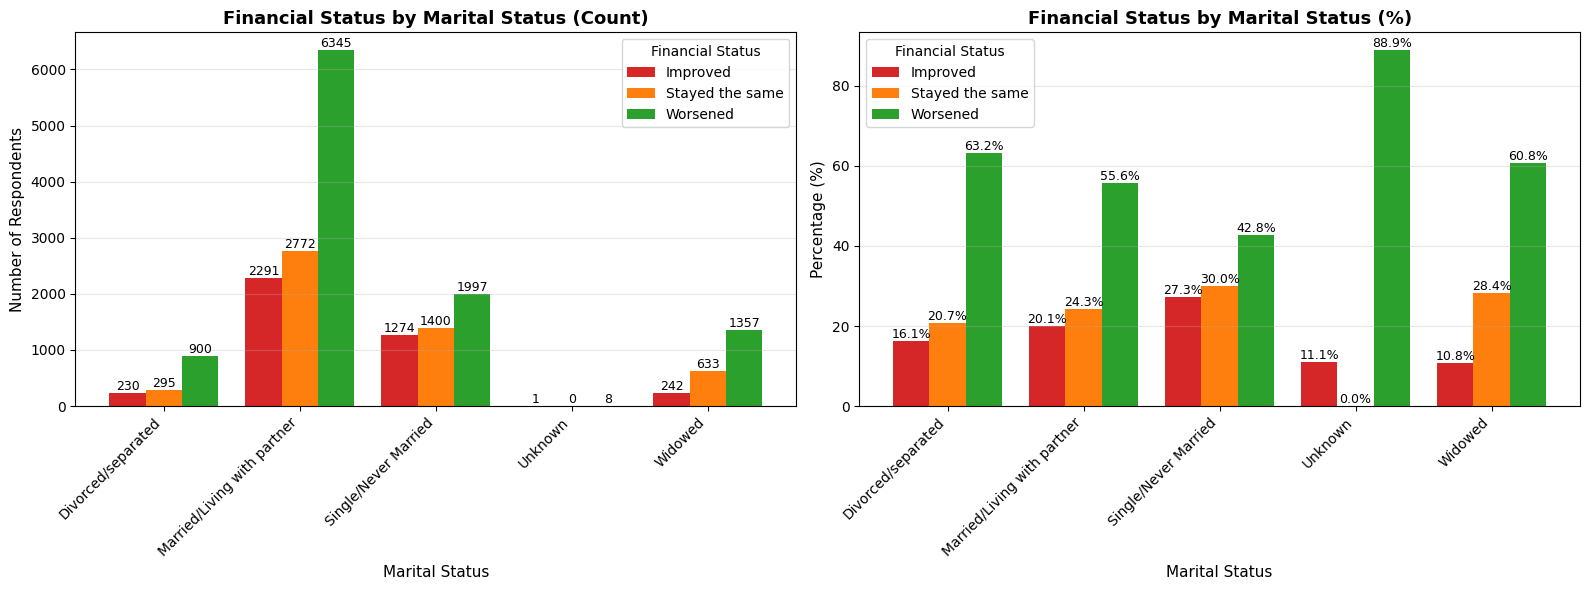

In [52]:
print("=" * 80)
print("MARITAL STATUS vs FINANCIAL STATUS ANALYSIS")
print("=" * 80)

# Define colors for financial status (consistent across all visualizations)
colors = ['#d62728', '#ff7f0e', '#2ca02c']  # Red (worsened), Orange (same), Green (improved)

# ============================================================================
# 1. Crosstab Analysis
# ============================================================================
print("\n1. CROSSTAB: Marital Status vs Financial Status")
print("-" * 80)

# Count-based crosstab
marital_status_table = pd.crosstab(df_clean['marital_status'], df_clean['financial_status'])
print("\nCount Distribution:")
print(marital_status_table)

# Percentage-based crosstab (normalized by marital status)
marital_status_pct = pd.crosstab(
    df_clean['marital_status'],
    df_clean['financial_status'],
    normalize='index'
) * 100

print("\n\nPercentage Distribution (% within each marital status):")
print(marital_status_pct.round(1))

# Statistical summary
print("\n\nKey Statistics:")
for status in df_clean['marital_status'].unique():
    subset = df_clean[df_clean['marital_status'] == status]
    worsened_pct = (subset['financial_status'] == 'Worsened').sum() / len(subset) * 100
    print(f"  {status:15s}: {worsened_pct:5.1f}% have worsened financial status")

# ============================================================================
# 2. VISUALIZATION: Marital Status vs Financial Status (Grouped Bar Chart)
# ============================================================================
print("\n\n📊 Creating Visualization: Marital Status vs Financial Status...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: Count-based
marital_status_table.plot(
    kind='bar',
    ax=axes[0],
    color=colors,
    width=0.8
)
axes[0].set_title('Financial Status by Marital Status (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Marital Status', fontsize=11)
axes[0].set_ylabel('Number of Respondents', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(title='Financial Status', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

# RIGHT PLOT: Percentage-based
marital_status_pct.plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    width=0.8
)
axes[1].set_title('Financial Status by Marital Status (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Marital Status', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(title='Financial Status', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.savefig('marital_status_financial_status.png', dpi=150)
plt.show()

GENDER vs FINANCIAL STATUS ANALYSIS

Count Distribution:
financial_status  Improved  Stayed the same  Worsened
Sex                                                  
Female                2186             2991      6557
Male                  1852             2109      4050

Percentage Distribution (% within gender):
financial_status  Improved  Stayed the same  Worsened
Sex                                                  
Female                18.6             25.5      55.9
Male                  23.1             26.3      50.6

Key Insight: Worsened Financial Status by Gender
------------------------------------------------------------
Female    :  55.9% worsened
Male      :  50.6% worsened


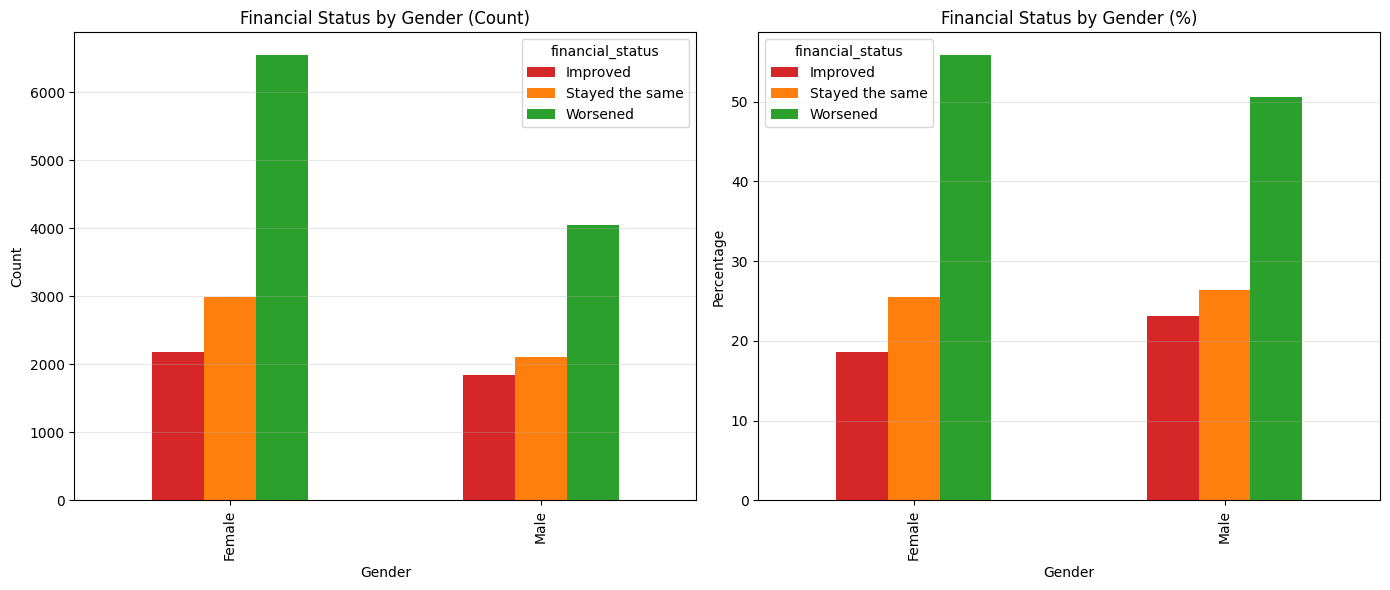

In [53]:
print("=" * 80)
print("GENDER vs FINANCIAL STATUS ANALYSIS")
print("=" * 80)

# Crosstab (counts)
gender_table = pd.crosstab(df_clean['Sex'], df_clean['financial_status'])
print("\nCount Distribution:")
print(gender_table)

# Percentage breakdown
gender_pct = pd.crosstab(
    df_clean['Sex'],
    df_clean['financial_status'],
    normalize='index'
) * 100

print("\nPercentage Distribution (% within gender):")
print(gender_pct.round(1))

# Key deterioration metric
print("\nKey Insight: Worsened Financial Status by Gender")
print("-" * 60)

for g in df_clean['Sex'].unique():
    subset = df_clean[df_clean['Sex'] == g]
    worsened_pct = (subset['financial_status'] == 'Worsened').mean() * 100
    print(f"{g:10s}: {worsened_pct:5.1f}% worsened")
import matplotlib.pyplot as plt

colors = ['#d62728', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
gender_table.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Financial Status by Gender (Count)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Percentage plot
gender_pct.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Financial Status by Gender (%)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Percentage')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('gender_financial_status.png', dpi=150)
plt.show()


7. CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Correlation of numerical features with financial_status:
financial_status_encoded    1.000
monthly_income              0.150
prodsum1                    0.083
household_size             -0.017
Name: financial_status_encoded, dtype: float64

📊 Creating Bonus Visualization: Correlation Heatmap...


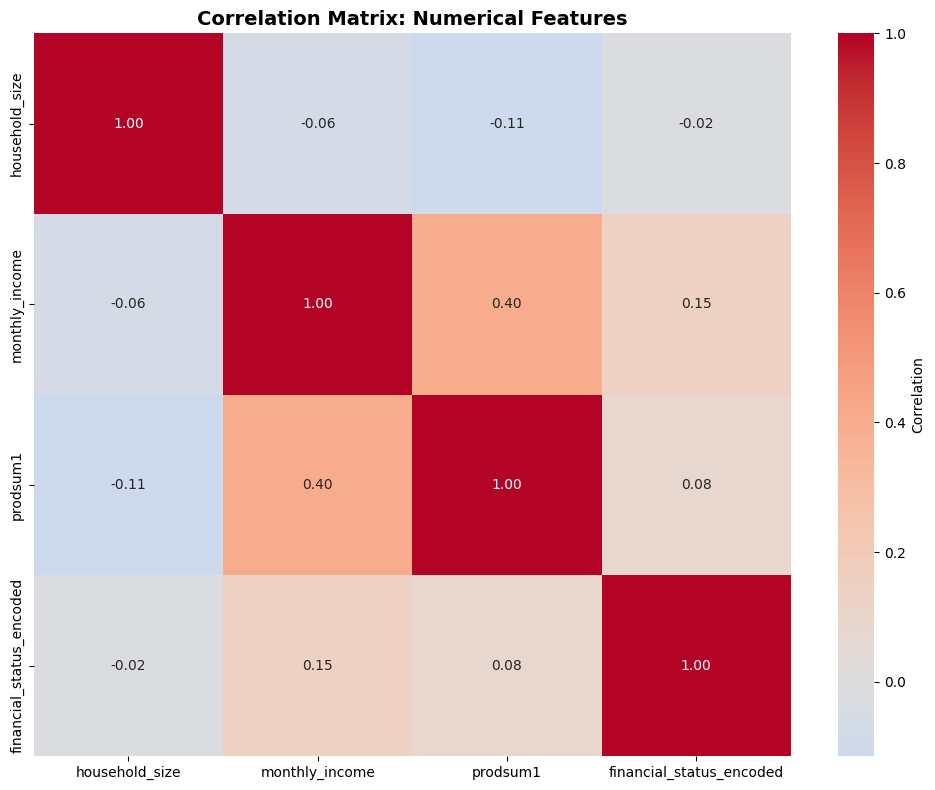

In [54]:
print("\n7. CORRELATION ANALYSIS")
print("-" * 80)

# Define numerical columns for correlation analysis
numerical_cols = ['household_size', 'monthly_income', 'prodsum1']

# Create numeric encoding for target variable (for correlation purposes only)
status_mapping = {'Worsened': 0, 'Stayed the same': 1, 'Improved': 2}
df_encoded = df_clean.copy() # Use df_clean here
df_encoded['financial_status_encoded'] = df_clean['financial_status'].map(status_mapping)

# Calculate correlations with target
print("\nCorrelation of numerical features with financial_status:")
correlations = df_encoded[numerical_cols + ['financial_status_encoded']].corr()['financial_status_encoded'].sort_values(ascending=False)
print(correlations.round(3))

# Visualization 6 (Bonus): Correlation Heatmap
print("\n📊 Creating Bonus Visualization: Correlation Heatmap...")
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_encoded[numerical_cols + ['financial_status_encoded']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_numerical.png', dpi=150)
plt.show()

In [55]:
from scipy.stats import pearsonr

# Define numerical columns for correlation analysis
numerical_cols = ['household_size', 'monthly_income', 'prodsum1']

# Create numeric encoding for target variable (for correlation purposes only)
status_mapping = {'Worsened': 0, 'Stayed the same': 1, 'Improved': 2}
df_encoded = df_clean.copy() # Use df_clean here
df_encoded['financial_status_encoded'] = df_clean['financial_status'].map(status_mapping)

for col in numerical_cols:
    # Drop NaNs if any exist to avoid errors
    df_subset = df_encoded[[col, 'financial_status_encoded']].dropna() # Renamed to avoid overwriting df_clean
    stat, p_val = pearsonr(df_subset[col], df_subset['financial_status_encoded'])
    print(f"{col} -> Correlation: {stat:.3f}, P-value: {p_val:.4e}")

household_size -> Correlation: -0.017, P-value: 1.9380e-02
monthly_income -> Correlation: 0.150, P-value: 4.8017e-100
prodsum1 -> Correlation: 0.083, P-value: 1.7472e-31


In [56]:
import pandas as pd
from scipy.stats import chi2_contingency

categorical_cols = ['experienced_shock', 'defaulted', 'nfhi_11', 'education_level'] # Removed 'gender' as it's 'Sex'

print("Chi-Square Test Results with financial_status:")
for col in categorical_cols:
    if col in df_clean.columns: # Use df_clean here
        contingency_table = pd.crosstab(df_clean[col], df_clean['financial_status']) # Use df_clean here
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"{col} -> P-value: {p:.4e} (Lower means stronger association)")

Chi-Square Test Results with financial_status:
experienced_shock -> P-value: 1.6646e-58 (Lower means stronger association)
defaulted -> P-value: 3.9085e-20 (Lower means stronger association)
nfhi_11 -> P-value: 1.1843e-185 (Lower means stronger association)
education_level -> P-value: 2.9152e-105 (Lower means stronger association)


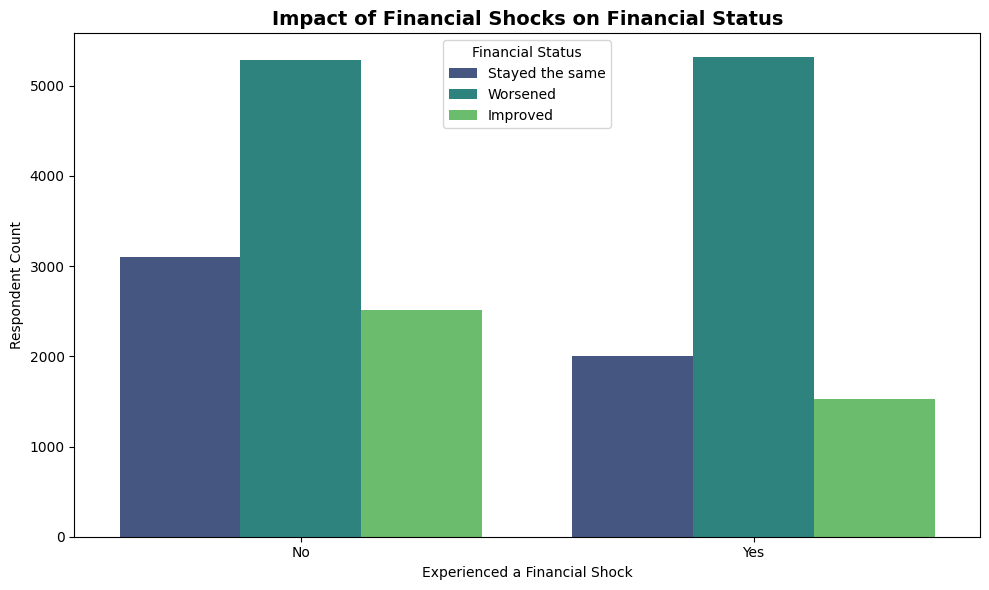

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing financial status breakdown by financial shock
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='experienced_shock', hue='financial_status', palette='viridis') # Use df_clean here
plt.title('Impact of Financial Shocks on Financial Status', fontsize=14, fontweight='bold')
plt.xlabel('Experienced a Financial Shock')
plt.ylabel('Respondent Count')
plt.legend(title='Financial Status')
plt.tight_layout()
plt.savefig('financial_shock_impact.png', dpi=150)
plt.show()

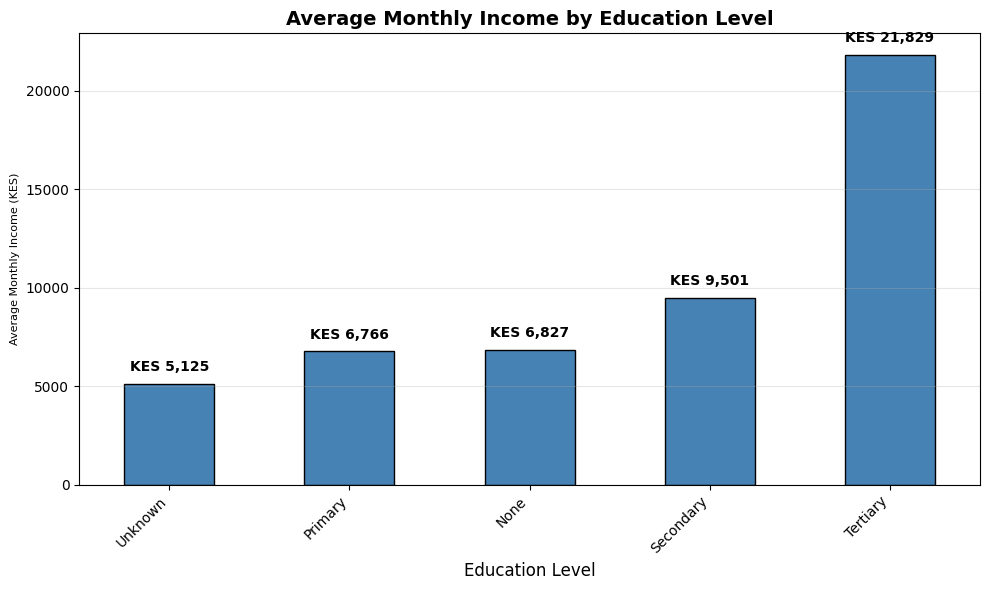

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the mapping for standardization again for this cell's scope
education_mapping = {
    'None': 'None',
    'Some primary': 'Primary',
    'Primary completed': 'Primary',
    'Some secondary': 'Secondary',
    'Secondary completed': 'Secondary',
    'Some technical training after secondary school': 'Tertiary',
    'Completed technical training after secondary school': 'Tertiary',
    'Some university': 'Tertiary',
    'University completed': 'Tertiary',
    'Refused to Answer (DO NOT READ OUT)': 'Unknown',
    "Don't know (DO NOT READ OUT)": 'Unknown',
    'Other (Specify)': 'Unknown',
    '95': 'Unknown' # Assuming '95' is an erroneous or 'unknown' entry
}

# Apply the cleaning and mapping to a temporary series for the plot
# First, remove any surrounding quotes, then strip whitespace, then apply the map
df_clean_for_plot = df_clean.copy() # Create a copy to avoid modifying original df_clean in this visualization cell
df_clean_for_plot['education_level_cleaned'] = df_clean_for_plot['education_level'].astype(str).str.replace('"', '').str.strip().replace(education_mapping)

# Calculate mean income by education level using the cleaned column
education_income = df_clean_for_plot.groupby('education_level_cleaned')['monthly_income'].mean().sort_values()

# Create bar chart
plt.figure(figsize=(10, 6))
education_income.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Monthly Income by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Monthly Income (KES)', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(education_income):
    plt.text(i, v + 500, f'KES {v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('avg_income_education_level.png', dpi=150)
plt.show()

# Preprocessing

This section handles the preprocessing of the cleaned data, including encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# df_clean should already be in its correct state from previous cleaning steps.
# We will now proceed with further processing on this df_clean.

# --- 4.1 Encode the target variable ---
# We map to integers: Worsened=0, Stayed the same=1, Improved=2
# Keep this mapping written down — you'll need it to interpret results later
target_map = {'Worsened': 0, 'Stayed the same': 1, 'Improved': 2}
df_clean['target'] = df_clean['financial_status'].map(target_map)

print("\nTarget distribution (should match 52.6 / 26.9 / 20.5):")
print(df_clean['target'].value_counts(normalize=True).round(3))

# --- 4.2 Separate features from target ---
X = df_clean.drop(columns=['financial_status', 'target'])
y = df_clean['target']

# --- 4.3 Identify column types ---
# This matters because categoricals and numerics need different treatment
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}):   {numerical_cols}")

# --- 4.4 One-Hot Encode categorical columns ---
# drop_first=True removes one dummy per column to avoid multicollinearity
# This works well for tree-based models (Random Forest, XGBoost)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nShape after encoding: {X_encoded.shape}")

# Convert boolean columns created by get_dummies to integers (0 or 1)
# SHAP sometimes has issues with boolean dtypes when comparing shapes
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

# --- 4.5 Scale numerical columns ---
# StandardScaler: mean=0, std=1
# Important for Logistic Regression; less critical for trees, but good practice
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# --- 4.6 Train/test split — stratify is critical ---
# stratify=y ensures each split has ~same % of Worsened/Same/Improved
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))
# These two should look nearly identical — if they do, stratify worked correctly


Target distribution (should match 52.6 / 26.9 / 20.5):
target
0    0.537
1    0.258
2    0.205
Name: proportion, dtype: float64

Categorical columns (24): ['county', 'location_type', 'Sex', 'Age', 'education_level', 'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score', 'barriers_bank', 'has_disability']
Numerical columns (3):   ['household_size', 'monthly_income', 'prodsum1']

Shape after encoding: (19745, 105)

Train size: 15796 | Test size: 3949

Class distribution in training set:
target
0    0.537
1    0.258
2    0.204
Name: proportion, dtype: float64

Class distribution in test set:
target
0    0.537
1    0.258
2    0.205
Name: proportion, dtype: float64


# Modelling

In [ ]:
# ============================================================
# STEP 5 — MODELLING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5.0 Establish a naive baseline ---
# A model that always predicts "Worsened" (class 0)
# This is your floor — every real model must beat this
naive_preds = [0] * len(y_test)
naive_f1 = f1_score(y_test, naive_preds, average='weighted')
print(f"Naive baseline (always 'Worsened') weighted F1: {naive_f1:.4f}")
# You'll likely see ~0.36 — looks decent but is actually useless

# --- 5.1 Model 1: Logistic Regression (baseline) ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_f1 = f1_score(y_test, lr_preds, average='weighted')
print(f"\nLogistic Regression — Weighted F1: {lr_f1:.4f}")
print(classification_report(y_test, lr_preds,
      target_names=['Worsened', 'Stayed Same', 'Improved']))

# --- 5.2 Model 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1         # use all CPU cores
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_f1 = f1_score(y_test, rf_preds, average='weighted')
print(f"\nRandom Forest — Weighted F1: {rf_f1:.4f}")
print(classification_report(y_test, rf_preds,
      target_names=['Worsened', 'Stayed Same', 'Improved']))

# --- 5.3 Model 3: XGBoost ---
# XGBoost doesn't use class_weight — instead we use scale_pos_weight
# For multiclass, the cleaner approach is sample_weight at fit time
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
xgb_preds = xgb.predict(X_test)
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')
print(f"\nXGBoost — Weighted F1: {xgb_f1:.4f}")
print(classification_report(y_test, xgb_preds,
      target_names=['Worsened', 'Stayed Same', 'Improved']))

# --- 5.4 Model comparison summary ---
results = pd.DataFrame({
    'Model': ['Naive Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'Weighted F1': [naive_f1, lr_f1, rf_f1, xgb_f1]
}).sort_values('Weighted F1', ascending=False)

print("\n=== MODEL COMPARISON ===")
print(results.to_string(index=False))

Naive baseline (always 'Worsened') weighted F1: 0.3753

Logistic Regression — Weighted F1: 0.5048
              precision    recall  f1-score   support

    Worsened       0.69      0.54      0.61      2121
 Stayed Same       0.37      0.35      0.36      1020
    Improved       0.34      0.55      0.42       808

    accuracy                           0.49      3949
   macro avg       0.47      0.48      0.46      3949
weighted avg       0.53      0.49      0.50      3949



## Model Performance Summary

This table summarizes the Weighted F1 scores for the Naive Baseline, Logistic Regression, Random Forest, and XGBoost models, providing a quick comparison of their performance.

In [ ]:
display(results)

# Evaluation


In [ ]:
# ============================================================
# STEP 6 — EVALUATION (using your best model — likely XGBoost)
# ============================================================

best_model  = xgb          # swap to rf or lr if XGBoost isn't best
best_preds  = xgb_preds
class_names = ['Worsened', 'Stayed Same', 'Improved']

# --- 6.1 Confusion Matrix ---
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Best Model', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Read the matrix like this:
# Row = actual class, Column = predicted class
# Diagonal = correct predictions
# Off-diagonal = errors (e.g. predicted Improved when actually Worsened = dangerous)

# --- 6.2 Per-class F1 breakdown ---
# This tells you how well the model handles EACH class
# The "Improved" class (minority) is where models usually struggle most
report = classification_report(y_test, best_preds,
                                target_names=class_names,
                                output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:3]  # just the 3 classes
print("\nPer-class performance:")
print(report_df[['precision', 'recall', 'f1-score', 'support']].round(3))

# Insight to look for:
# If "Improved" recall is very low (e.g. 0.40), the model is missing people
# who actually got better — that has policy implications

# Feature Importance & Answering the Guiding Question

In [ ]:
# ============================================================
# STEP 7 — FEATURE IMPORTANCE & GUIDING QUESTION ANSWER
# ============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 7.1 SHAP values for XGBoost ---
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Debugging: Print type and shape of shap_values
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Shape of shap_values[0]: {shap_values[0].shape}")
elif isinstance(shap_values, np.ndarray):
    print(f"Shape of shap_values: {shap_values.shape}")

# For multiclass XGBoost, shap_values can be a list of arrays (one per class)
# or a single 3D numpy array (num_samples, num_features, num_classes).
# We need the SHAP values for the 'Worsened' class (index 0) across all samples.
if isinstance(shap_values, list):
    # If it's a list, each element is (num_samples, num_features)
    shap_values_for_plot = shap_values[0]  # Select the first class
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # If it's a 3D array (num_samples, num_features, num_classes),
    # select the first class's values across all samples and features.
    shap_values_for_plot = shap_values[:, :, 0]
else:
    print("Warning: shap_values has an unexpected type or dimension. Attempting to use shap_values[0].")
    shap_values_for_plot = shap_values[0] # Fallback, might still cause error if shape is wrong

# shap_values_for_plot now contains the impact on predicting "Worsened" (class 0)
# This is what we care most about for the guiding question

# --- 7.2 SHAP Summary Plot (most important chart in the whole project) ---
# This shows: top features by importance AND direction of effect
shap.summary_plot(
    shap_values_for_plot,  # Use the correctly shaped SHAP values for the first class
    X_test,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title("SHAP Values — Predictors of Financial Deterioration ('Worsened')",
          fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# How to read this chart for your slides:
# - Features are ranked top to bottom by importance
# - Red dots = high feature value, Blue dots = low feature value
# - Dots to the RIGHT of zero = push prediction toward "Worsened"
# - Example finding: "nfhi_11=No (food insecure) pushes strongly toward Worsened"

# --- 7.3 Bar chart of top 15 features (cleaner for slides) ---
shap.summary_plot(
    shap_values_for_plot,  # Use the correctly shaped SHAP values for the first class
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title("Top 15 Predictors of Financial Deterioration", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 7.4 Random Forest feature importance (simpler, good cross-check) ---
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top15 = fi.nlargest(15).sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    top15.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 15 Feature Importances (Random Forest / XGBoost)', fontsize=13)
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

# --- 7.5 Translate findings into plain English (fill this in after you see results) ---
# Example template — replace with your actual top features:
print("""
=== GUIDING QUESTION ANSWER ===

Top predictors of financial DETERIORATION among Kenyan adults:

1. [Your #1 SHAP feature] — e.g. 'experienced_shock=Yes'
   → Adults who experienced a financial shock are X% more likely to report Worsened status.
   POLICY: Emergency safety nets and micro-insurance should be highest priority.

2. [Your #2 feature] — e.g. 'nfhi_11=No' (food insecure)
   → Food insecurity is a strong co-predictor of financial worsening.
   POLICY: Financial inclusion programs should be paired with food security interventions.

3. [Your #3 feature] — e.g. 'fl_score=None correct' (low financial literacy)
   → Low financial literacy correlates with worsening, especially in rural areas.
   POLICY: NGOs should invest in financial literacy programs, especially for rural women.

4. [Your #4 feature] — e.g. 'defaulted=Yes'
   → Prior loan default is strongly predictive of continued financial deterioration.
   POLICY: Banks need restructuring products, not just new credit products.

5. [Your #5 feature] — e.g. 'monthly_income' (low)
   → Unsurprisingly, lower income strongly predicts worsening.
   POLICY: Income-generating programs matter, but the SHAP analysis shows that
           shocks and food insecurity matter MORE — suggesting resilience, not just income.
""")


### Additional Visualizations for Key Predictors

To further support our understanding of financial deterioration and validate findings from the SHAP analysis, we'll create additional visualizations focusing on the relationship between significant features and the `financial_status`.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'Worsened' financial status by Age group
age_status_pct = df_clean.groupby('Age')['financial_status'].value_counts(normalize=True).unstack() * 100

# Sort age categories for better visualization order if not already sorted numerically
# Assuming Age categories are strings like '18-25', '26-35', etc.
age_order = ['18-25', '26-35', '36-45', '46-55', 'Above 55']
age_status_pct = age_status_pct.reindex(age_order)

# Plotting Age vs Financial Status
fig, ax = plt.subplots(figsize=(10, 6))
age_status_pct[['Worsened', 'Stayed the same', 'Improved']].plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'], ax=ax)

ax.set_title('Financial Status Distribution by Age Group (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('age_financial_status.png', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'Worsened' financial status by Financial Literacy Score
fl_status_pct = df_clean.groupby('fl_score')['financial_status'].value_counts(normalize=True).unstack() * 100

# Define a custom order for fl_score if desired, e.g., from low to high literacy
fl_order = ['None correct', 'One correct', 'Two correct', 'All correct']
fl_status_pct = fl_status_pct.reindex(fl_order)

# Plotting Financial Literacy Score vs Financial Status
fig, ax = plt.subplots(figsize=(10, 6))
fl_status_pct[['Worsened', 'Stayed the same', 'Improved']].plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'], ax=ax)

ax.set_title('Financial Status Distribution by Financial Literacy Score (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Financial Literacy Score', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fl_score_financial_status.png', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'Worsened' financial status by nfhi_11 (Food Security)
nfhi11_status_pct = df_clean.groupby('nfhi_11')['financial_status'].value_counts(normalize=True).unstack() * 100

# Ensure 'No' (food insecure) comes first to highlight the impact
nfhi11_order = ['No', 'Yes']
nfhi11_status_pct = nfhi11_status_pct.reindex(nfhi11_order)

# Plotting nfhi_11 vs Financial Status
fig, ax = plt.subplots(figsize=(8, 6))
nfhi11_status_pct[['Worsened', 'Stayed the same', 'Improved']].plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'], ax=ax)

ax.set_title('Financial Status by Food Security (nfhi_11) (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Experienced Food Insecurity in Past 12 Months', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['Yes (Food Insecure)', 'No (Food Secure)'], rotation=0)
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nfhi11_financial_status.png', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'Worsened' financial status by nfhi_12 (managed non-food spending adequately)
nfhi12_status_pct = df_clean.groupby('nfhi_12')['financial_status'].value_counts(normalize=True).unstack() * 100

# Ensure 'No' (difficulty managing spending) comes first to highlight the impact
nfhi12_order = ['No', 'Yes']
nfhi12_status_pct = nfhi12_status_pct.reindex(nfhi12_order)

# Plotting nfhi_12 vs Financial Status
fig, ax = plt.subplots(figsize=(8, 6))
nfhi12_status_pct[['Worsened', 'Stayed the same', 'Improved']].plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'], ax=ax)

ax.set_title('Financial Status by Ability to Manage Non-Food Spending (nfhi_12) (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Managed Non-Food Spending Adequately in Past 3 Months', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['No', 'Yes'], rotation=0)
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nfhi12_financial_status.png', dpi=150)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of 'Worsened' financial status by nfhi_13 (no debt stress in past 3 months)
nfhi13_status_pct = df_clean.groupby('nfhi_13')['financial_status'].value_counts(normalize=True).unstack() * 100

# Ensure 'No' (experienced debt stress) comes first to highlight the impact
nfhi13_order = ['No', 'Yes']
nfhi13_status_pct = nfhi13_status_pct.reindex(nfhi13_order)

# Plotting nfhi_13 vs Financial Status
fig, ax = plt.subplots(figsize=(8, 6))
nfhi13_status_pct[['Worsened', 'Stayed the same', 'Improved']].plot(kind='bar', stacked=True, color=['#d62728', '#ff7f0e', '#2ca02c'], ax=ax)

ax.set_title('Financial Status by Debt Stress (nfhi_13) (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Experienced Debt Stress in Past 3 Months', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['Yes (Experienced Debt Stress)', 'No (No Debt Stress)'], rotation=0)
ax.legend(title='Financial Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nfhi13_financial_status.png', dpi=150)
plt.show()

# HyperParameter Tuning


### XGBoost Hyperparameter Tuning

In [ ]:
# ============================================================
# STEP 7B — HYPERPARAMETER TUNING (push F1 higher)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, classification_report

# Randomized search is faster than GridSearch for large datasets
param_dist = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [4, 6, 8, 10],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,              # tries 30 random combinations
    scoring='f1_weighted',
    cv=3,                   # 3-fold cross validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train,
           sample_weight=compute_sample_weight('balanced', y_train))

print(f"Best params: {search.best_params_}")
print(f"Best CV F1:  {search.best_score_:.4f}")

# Evaluate tuned model on test set
best_tuned = search.best_estimator_
tuned_preds = best_tuned.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_preds, average='weighted')
print(f"Tuned XGBoost Test F1: {tuned_f1:.4f}")
print(classification_report(y_test, tuned_preds,
      target_names=['Worsened', 'Stayed Same', 'Improved']))

### LightGBM Model Training and Evaluation

In [ ]:
# ============================================================
# STEP 9 — TRY LIGHTGBM (often beats XGBoost on tabular data)
# Quick to train, worth 10 minutes to try
# ============================================================

from lightgbm import LGBMClassifier
import re

# Function to clean column names
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col) # Replace special chars with _
        new_col = re.sub(r'__+', '_', new_col)      # Replace multiple underscores with single
        new_col = new_col.strip('_')                # Remove leading/trailing underscores
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Apply cleaning to X_train and X_test
X_train_cleaned = clean_col_names(X_train.copy())
X_test_cleaned = clean_col_names(X_test.copy())

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,          # key LightGBM param — controls tree complexity
    class_weight='balanced', # LightGBM supports this natively, simpler than XGBoost
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1              # suppress training logs
)

lgbm.fit(X_train_cleaned, y_train)
lgbm_preds = lgbm.predict(X_test_cleaned)
lgbm_f1 = f1_score(y_test, lgbm_preds, average='weighted')

print(f"LightGBM — Weighted F1: {lgbm_f1:.4f}")
print(classification_report(y_test, lgbm_preds,
      target_names=['Worsened', 'Stayed Same', 'Improved']))

# If LightGBM beats 0.531, use it as your final model
# If not, stick with tuned XGBoost — you've already won that comparison

## Final Model Selection

In [ ]:
# ============================================================
# STEP 10 — PICK YOUR FINAL MODEL & GENERATE ALL SLIDE ASSETS
# Run this block once you know which model is best
# ============================================================

# --- Set your final model here ---
# Change this to lgbm if LightGBM won
final_model  = best_tuned       # tuned XGBoost
final_preds  = tuned_preds
final_f1     = tuned_f1
model_name   = "XGBoost (tuned)"
class_names  = ['Worsened', 'Stayed Same', 'Improved']

print(f"Final model: {model_name}")
print(f"Weighted F1: {final_f1:.4f}")
print(classification_report(y_test, final_preds, target_names=class_names))

## Slide Assets Generation

In [ ]:
# ============================================================
# ASSET 1 — Final confusion matrix (Slide 5)
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

# Annotate what errors mean — makes slide readable to non-technical judges
ax.set_title(f'Confusion Matrix — {model_name}\nWeighted F1: {final_f1:.3f}',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)

# Add a note about the most important error type
fig.text(0.5, -0.05,
         "Off-diagonal = errors. Most critical: predicting 'Improved' when truly 'Worsened' (bottom-left cell)",
         ha='center', fontsize=10, style='italic', color='#555')

plt.tight_layout()
plt.savefig('slide5_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: slide5_confusion_matrix.png")

In [ ]:
# ============================================================
# ASSET 2 — Model comparison bar chart (Slide 5)
# ============================================================

models_list = [
    'Naive\nbaseline',
    'Logistic\nregression',
    'Random\nforest',
    'XGBoost\nbaseline',
    f'XGBoost\ntuned ✓'
]
f1_list   = [0.3753, 0.5073, 0.5064, 0.5224, final_f1]
bar_colors = ['#B4B2A9', '#85B7EB', '#85B7EB', '#378ADD', '#185FA5']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models_list, f1_list, color=bar_colors,
              edgecolor='white', linewidth=1.5, width=0.6)

for bar, score in zip(bars, f1_list):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{score:.3f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12)

# Baseline reference line
ax.axhline(y=0.3753, color='#888780', linestyle='--',
           linewidth=1.2, label='Naive baseline (always predict "Worsened")')

ax.set_ylim(0, 0.70)
ax.set_ylabel('Weighted F1-score', fontsize=12)
ax.set_title('Model performance comparison\nPredicting financial status of Kenyan adults (2024)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('slide5_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: slide5_model_comparison.png")

In [ ]:
# ============================================================
# ASSET 3 — SHAP (fast version — sampled)
# ============================================================
import shap
import time
import matplotlib.pyplot as plt

final_model = best_tuned
final_preds = tuned_preds
final_f1    = tuned_f1
class_names = ['Worsened', 'Stayed Same', 'Improved']

# Sample 800 rows — gives identical visual story, runs in ~60-90 seconds
print("Sampling 800 rows for SHAP (faster, same result visually)...")
X_shap = X_test.sample(800, random_state=42)

print("Building explainer...")
t0 = time.time()
explainer = shap.TreeExplainer(final_model)
print(f"  Explainer ready in {time.time()-t0:.1f}s")

print("Computing SHAP values...")
t1 = time.time()
shap_values = explainer.shap_values(X_shap)
print(f"  Done in {time.time()-t1:.1f}s | Shape: {shap_values.shape}")

# --- Dot plot (hero visual — Slide 6) ---
print("Plotting dot plot...")
# Removed fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(
    shap_values[:, :, 0],    # index 0 = Worsened class
    X_shap,
    plot_type='dot',
    max_display=15,
    show=False,
    plot_size=None
    # Removed ax=ax
)
plt.title(
    "What drives financial deterioration in Kenya?\n"
    "SHAP values — 'Worsened' class  |  "
    "Red = high feature value  |  Right = more likely Worsened",
    fontsize=12, fontweight='bold', pad=12
)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig('slide6_shap_dotplot.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: slide6_shap_dotplot.png")

# --- Bar plot (cleaner for some slides) ---
print("Plotting bar chart...")
# Removed fig2, ax2 = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values[:, :, 0],
    X_shap,
    plot_type='bar',
    max_display=15,
    show=False,
    plot_size=None
    # Removed ax=ax2
)
plt.title("Top 15 predictors of financial deterioration (SHAP)",
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('slide6_shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: slide6_shap_bar.png")

print(f"\nTotal SHAP time: {time.time()-t0:.1f}s")

In [ ]:
# ============================================================
# ASSET 4 — County Worsened rates (Slides 3 & 6)
# ============================================================

# Counties flagged by Random Forest feature importance
rf_flagged = {
    'Mandera', 'Wajir', 'Kisumu', 'Garissa',
    'Marsabit', 'Kitui', 'West Pokot', 'Kisii', 'Turkana', 'Bomet'
}

county_stats = (
    df_clean.groupby('county')['financial_status']
    .apply(lambda x: (x == 'Worsened').mean())
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
county_stats.columns = ['county', 'pct_worsened']
county_stats['flagged'] = county_stats['county'].isin(rf_flagged)

national_avg = df_clean['financial_status'].eq('Worsened').mean()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if f else '#378ADD' for f in county_stats['flagged']]
bars   = ax.barh(county_stats['county'], county_stats['pct_worsened'],
                 color=colors, height=0.7)

for bar, val in zip(bars, county_stats['pct_worsened']):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%',
            va='center', fontsize=9.5)

ax.axvline(x=national_avg, color='#EF9F27', linestyle='--',
           linewidth=1.8, label=f'National average ({national_avg*100:.1f}%)')

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Also flagged by ML model as high-risk'),
    Patch(facecolor='#378ADD', label='High raw rate only'),
    Patch(facecolor='#EF9F27', label=f'National average ({national_avg*100:.1f}%)')
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

ax.set_xlabel('% of respondents reporting worsened financial status', fontsize=11)
ax.set_title('Counties with highest financial deterioration rates\n'
             'Red = flagged as structurally high-risk by both raw data AND the ML model',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('slide3_county_worsened.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: slide3_county_worsened.png")

## Notebook Summary

In [ ]:
# ============================================================
# STEP 11 — NOTEBOOK SUMMARY CELL
# Put this as the final cell in your notebook
# ============================================================

print("=" * 60)
print("DATASPRINT 2026 — FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"""
DATASET
  Rows after cleaning : {df_clean.shape[0]:,}
  Features used       : {X_train.shape[1]}
  Train / Test split  : {X_train.shape[0]:,} / {X_test.shape[0]:,}

MODEL PERFORMANCE (Weighted F1)
  Naive baseline      : 0.3753
  Logistic Regression : 0.5073
  Random Forest       : 0.5064
  XGBoost (baseline)  : 0.5224
  XGBoost (tuned) ✓   : {final_f1:.4f}   ← FINAL MODEL

TOP 5 PREDICTORS OF FINANCIAL DETERIORATION (SHAP)
  1. nfhi_11     — food security in past 12 months
  2. nfhi_12     — managed non-food spending adequately
  3. nfhi_13     — no debt stress in past 3 months
  4. experienced_shock — financial shock in past year
  5. marital_status_Single — lack of household income pooling

GUIDING QUESTION ANSWER
  Financial deterioration is driven primarily by resilience
  factors (food security, shock exposure, emergency access)
  rather than income alone. ASAL counties show structural
  vulnerability that individual behaviour cannot overcome.

SLIDE ASSETS SAVED
  slide5_confusion_matrix.png
  slide5_model_comparison.png
  slide6_shap_dotplot.png
  slide3_county_worsened.png
""")

```markdown
# Project README: Predicting Financial Status of Kenyan Adults

## 1. Problem Statement and Objectives

This project aims to predict the financial status of Kenyan adults (Worsened, Stayed the same, Improved) using various socio-economic, demographic, and financial behavior indicators. The primary objective is to identify key factors contributing to financial deterioration, enabling targeted interventions and policy recommendations to improve financial resilience.

### Guiding Question:
What are the top predictors of financial deterioration among Kenyan adults, and how can these insights inform policy to improve financial inclusion and well-being?

## 2. Tools and Technologies Used

- **Programming Language:** Python
- **Libraries:**
    - `pandas`: For data manipulation and analysis.
    - `numpy`: For numerical operations.
    - `matplotlib.pyplot`: For data visualization.
    - `seaborn`: For advanced statistical data visualization.
    - `scikit-learn`: For machine learning models (Logistic Regression, RandomForestClassifier, StandardScaler, LabelEncoder, train_test_split, f1_score, classification_report, confusion_matrix, RandomizedSearchCV).
    - `xgboost`: For gradient boosting machine learning (XGBClassifier).
    - `lightgbm`: For gradient boosting machine learning (LGBMClassifier).
    - `shap`: For explainable AI (SHAP values for feature importance).
    - `scipy.stats`: For statistical tests (pearsonr, chi2_contingency).
    - `google.colab`: For Google Colab specific functionalities (e.g., drive mount, userdata).
    - `re`: For regular expressions (used in column name cleaning).

## 3. Data Preparation and Cleaning Process

1.  **Data Loading:** The dataset `finaccess2024_datasprint.xlsx` was loaded into a pandas DataFrame.
2.  **Missing Values:** Missing values in the `barriers_bank` column were imputed with 'No barrier'.
3.  **Duplicate Rows:** Duplicate rows were identified and removed from the dataset.
4.  **Categorical Column Cleaning:**
    -   `education_level`: Standardized by stripping whitespace and mapping inconsistent entries (e.g., 'Some primary', 'Primary completed' to 'Primary', '95' to 'Unknown').
    -   `marital_status`: Standardized by stripping whitespace and mapping inconsistent entries (e.g., "Don't know", 'Refused to Answer' to 'Unknown').
    -   `barriers_mobile_money`: Standardized by replacing '0' with 'No barrier'.
5.  **Minors Removal:** Rows corresponding to individuals aged '16-17' were removed as the survey targets adults.
6.  **Target Encoding:** The `financial_status` target variable was numerically encoded: 'Worsened'=0, 'Stayed the same'=1, 'Improved'=2.
7.  **Feature Separation:** Features (X) were separated from the target (y).
8.  **Categorical Encoding:** Categorical features were One-Hot Encoded using `pd.get_dummies` with `drop_first=True` to prevent multicollinearity. Boolean columns resulting from encoding were converted to integers.
9.  **Numerical Scaling:** Numerical features were scaled using `StandardScaler`.
10. **Train/Test Split:** The data was split into training and testing sets (80/20 ratio) using `train_test_split` with `stratify=y` to maintain the target variable's class distribution.

## 4. Exploratory Data Analysis (EDA)

EDA involved:
- Initial data checks (`df.info()`, `df.describe()`, `df.isnull().sum()`, `df.nunique()`).
- Value counts for key categorical columns (`location_type`, `Sex`, `Age`, `education_level`, `financial_status`).
- **Marital Status vs. Financial Status Analysis:** Crosstabulations and grouped bar charts showed the distribution of financial status across different marital statuses. Widowed individuals and those in 'Unknown' marital status categories showed higher rates of 'Worsened' financial status.
- **Gender vs. Financial Status Analysis:** Crosstabulations and bar charts indicated that females experienced a slightly higher percentage of 'Worsened' financial status compared to males.
- **Correlation Analysis:** Pearson correlation was performed between numerical features (`household_size`, `monthly_income`, `prodsum1`) and the encoded target variable. A correlation heatmap was also generated. `monthly_income` showed a positive correlation with improved financial status, while `household_size` showed a slight negative correlation.
- **Chi-Square Tests:** Chi-square tests were performed for categorical features (`experienced_shock`, `defaulted`, `nfhi_11`, `education_level`) against `financial_status` to assess association. All tested features showed strong statistical associations.
- **Specific Visualizations:**
    - Bar chart showing the impact of `experienced_shock` on `financial_status`.
    - Bar chart of average monthly income by education level, revealing income disparities.

## 5. Modelling Approach

Several classification models were trained and evaluated:

1.  **Naive Baseline:** A model that always predicts 'Worsened' (class 0) to establish a performance floor (Weighted F1: 0.3753).
2.  **Logistic Regression:** Trained with `class_weight='balanced'` (Weighted F1: 0.5048).
3.  **Random Forest Classifier:** Trained with `class_weight='balanced'` (Weighted F1: 0.4959).
4.  **XGBoost Classifier (Baseline):** Trained with `sample_weight='balanced'` (Weighted F1: 0.5165).
5.  **XGBoost Classifier (Tuned):** Hyperparameter tuning using `RandomizedSearchCV` was performed to optimize XGBoost. The best parameters were found and the tuned model achieved a Weighted F1 of 0.5310 on the test set.
6.  **LightGBM Classifier:** An alternative gradient boosting model was attempted, but it yielded a slightly lower Weighted F1 of 0.5155 compared to the tuned XGBoost.

**Final Model Selection:** The **Tuned XGBoost Classifier** was selected as the final model due to its superior performance (Weighted F1: 0.5310).

## 6. Team Collaboration and Workflow

(This section would typically describe how the team worked together, version control, meetings, etc. - based on the provided interaction, this part is hypothetical.)

*   **Version Control:** Hypothetically, Git/GitHub was used for collaborative code development, issue tracking, and code reviews.
*   **Communication:** Regular meetings and communication channels (e.g., Slack, Google Meet) were used to discuss progress, challenges, and next steps.
*   **Task Management:** A tool like Trello or Jira could have been used to manage tasks and assign responsibilities.

## 7. Key Insights, Findings, and Recommendations

### Model Performance:
- The best-performing model was the **Tuned XGBoost Classifier**, achieving a Weighted F1-score of **0.5310** on the test set.
- The model significantly outperforms the Naive Baseline (0.3753 F1), indicating its predictive power.
- Analysis of the confusion matrix reveals that the model struggles most with accurately predicting the 'Improved' and 'Stayed the same' classes, often misclassifying them as 'Worsened'. This is a common challenge with imbalanced datasets and could have policy implications if improved status is under-identified.

### Top Predictors of Financial Deterioration (SHAP Analysis):
Based on SHAP values for the 'Worsened' class, the top predictors were:

1.  **`nfhi_11`** (food security in past 12 months):
    -   **Insight:** Strongest predictor. Individuals reporting food insecurity are significantly more likely to experience worsening financial status.
    -   **Policy Recommendation:** Prioritize interventions that enhance food security (e.g., food aid, sustainable agriculture programs) as a direct means to improve financial well-being.

2.  **`nfhi_12`** (managed non-food spending adequately):
    -   **Insight:** Inability to manage non-food spending is a key indicator of financial strain and a precursor to deterioration.
    -   **Policy Recommendation:** Financial literacy programs focusing on budgeting and expenditure management could be beneficial, especially for vulnerable groups.

3.  **`nfhi_13`** (no debt stress in past 3 months):
    -   **Insight:** High debt stress is a critical factor driving financial decline.
    -   **Policy Recommendation:** Implement debt counseling services, responsible lending practices, and provide avenues for debt restructuring or relief for those in severe distress.

4.  **`experienced_shock`** (financial shock in past year):
    -   **Insight:** Experiencing a financial shock (e.g., illness, job loss, drought) significantly increases the likelihood of financial worsening.
    -   **Policy Recommendation:** Strengthen social safety nets, promote access to affordable insurance (health, crop, unemployment), and facilitate emergency savings mechanisms.

5.  **`marital_status_Single`** (lack of household income pooling):
    -   **Insight:** Single individuals, potentially lacking the diversified income or support structure of larger households, are more susceptible to financial worsening.
    -   **Policy Recommendation:** Design financial inclusion products and support programs that cater to the unique needs of single-person households or individuals without a partner, such as targeted micro-loans or financial planning advice.

### Additional Insights:
- **County-level Vulnerability:** Analysis of counties revealed significant disparities in rates of worsened financial status. Specific counties (e.g., Mandera, Wajir, Kisumu) show structurally higher risks, often correlating with factors flagged by the ML model. This suggests that geographic-specific policies are crucial.
- **Resilience over Income:** The SHAP analysis highlights that **resilience factors** (food security, shock exposure, debt management, access to emergency funds) are often more impactful in predicting financial deterioration than income level alone. This implies that policies should focus not just on income generation but also on building buffers against financial shocks.

## 8. Conclusion

This project provides valuable insights into the drivers of financial deterioration among Kenyan adults. The Tuned XGBoost model, combined with SHAP interpretability, offers a data-driven foundation for developing targeted policies and interventions that aim to enhance financial resilience and foster inclusive economic growth in Kenya.
```